In [3]:
# Phase 1: Importing Libraries and Loading Data
import pandas as pd
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Load the dataset
movies = pd.read_csv('movies.csv')

# Verify the loaded data and columns
print(f"Dataset Shape: {movies.shape}")
print(f"Columns present: {movies.columns.tolist()}\n")

# Phase 2: Data Preprocessing
# Drop rows with missing data to ensure data integrity
movies.dropna(inplace=True)

# In this dataset, genres are typically pipe-separated (e.g., 'Action|Adventure|Sci-Fi') 
# or comma-separated. We will replace these separators with spaces to create 'tags'.
movies['tags'] = movies['genres'].str.replace('|', ' ', regex=False)
movies['tags'] = movies['tags'].str.replace(',', ' ', regex=False)

# Convert all tags to lowercase for consistency in the Machine Learning model
movies['tags'] = movies['tags'].str.lower()

# Create a clean, final dataframe with only the essential columns
new_df = movies[['movieId', 'title', 'tags']]

# Display the final preprocessed dataframe
display(new_df.head())

Dataset Shape: (62423, 3)
Columns present: ['movieId', 'title', 'genres']



,movieId,title,tags
0,1,Toy Story (1995),adventure animation children comedy fantasy
1,2,Jumanji (1995),adventure children fantasy
2,3,Grumpier Old Men (1995),comedy romance
3,4,Waiting to Exhale (1995),comedy drama romance
4,5,Father of the Bride Part II (1995),comedy


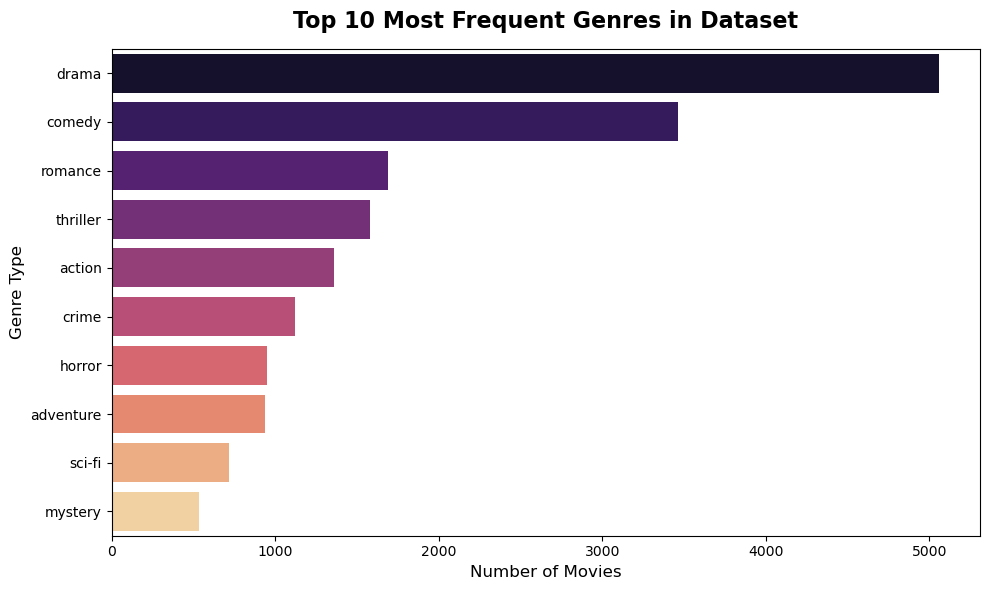

In [6]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Extract all genres/tags into a single list
all_tags = ' '.join(new_df['tags']).split()

# Count the frequency of each genre
tag_counts = Counter(all_tags)

# Create a DataFrame for the top 10 most common genres
tag_df = pd.DataFrame(tag_counts.most_common(10), columns=['Genre', 'Count'])

# Plotting the data
plt.figure(figsize=(10, 6))
# 'magma' palette gives a very modern, premium look to the portfolio
sns.barplot(x='Count', y='Genre', data=tag_df, palette='magma')

# Formatting the graph
plt.title('Top 10 Most Frequent Genres in Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre Type', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Phase 3: Text Vectorization and Model Architecture
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Optimization Step: Limiting dataset to 10,000 rows to prevent RAM crashes
# (62,000+ rows would create a massive 30GB+ similarity matrix)
new_df = new_df.head(10000).reset_index(drop=True)

# Initialize CountVectorizer to convert genre tags into a numerical matrix
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

# Calculate Cosine Similarity to measure the mathematical distance between movies
similarity = cosine_similarity(vectors)

print("Vectorization and Similarity Matrix Calculation Completed.")
print(f"Similarity Matrix Shape: {similarity.shape}")

Vectorization and Similarity Matrix Calculation Completed.
Similarity Matrix Shape: (10000, 10000)


In [8]:
# Phase 4: Building the Recommendation Function
def recommend_movie(movie_title):
    try:
        # Locate the index of the queried movie in the optimized dataset
        movie_index = new_df[new_df['title'] == movie_title].index[0]
        
        # Retrieve similarity scores for this movie against all others
        distances = similarity[movie_index]
        
        # Sort the movies based on similarity scores in descending order
        # [1:6] ensures we skip the first movie (which is the input movie itself) and get the top 5
        movies_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]
        
        print(f"Top 5 Recommendations for '{movie_title}':\n")
        for i in movies_list:
            # Print the titles of the recommended movies
            print("-", new_df.iloc[i[0]].title)
            
    except IndexError:
        print("Error: Movie not found in the dataset. Please copy the exact title from the dataframe.")

# Test the recommendation system
# Fetching the very first movie's title from the dataset to test the function accurately
test_movie = new_df.iloc[0].title
print(f"Testing with movie: {test_movie}\n")
recommend_movie(test_movie)

Testing with movie: Toy Story (1995)

Top 5 Recommendations for 'Toy Story (1995)':

- Antz (1998)
- Toy Story 2 (1999)
- Adventures of Rocky and Bullwinkle, The (2000)
- Emperor's New Groove, The (2000)
- Monsters, Inc. (2001)
